# 06b — Sensitivity Analysis: When Does the MDP Matter?
**Phase 6b: Cost, Lead Time, and Shelf Life Sensitivity**

How does the MDP's advantage over the best static order-up-to policy change
under different operating conditions?

Three dimensions:
1. **Cost parameters** — vary cu/co ratio (4 scenarios)
2. **Lead time variability** — sweep P(L=1) from deterministic to noisy
3. **Shelf life** — 2-day, 3-day (base), 4-day (changes state space)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time, ctypes, subprocess, tempfile, shutil
from math import comb

DATA_DIR = "../data/processed"
FIG_DIR  = "../outputs/figures"
TBL_DIR  = "../outputs/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

# ── Load demand PMF ──
P_df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_P_of_D.csv"))
demand_values = P_df["Demand_D"].to_numpy().astype(np.int32)
demand_probs  = P_df["P_smoothed"].to_numpy().astype(np.float64)
n_demands = len(demand_values)
D_MAX = int(demand_values[-1])   # 25

# ── Defaults ──
N_RUNS = 1000
T = 364
SEED = 42
GAMMA = 0.99
CAP = 35
MAX_ITER = 300

# ── Base economics ──
SELL_PRICE, UNIT_COST, SALVAGE = 4.0, 1.50, 0.0
P_LEAD_1 = 0.8

print(f"Demand PMF loaded: D = 0..{D_MAX}, {n_demands} values")
print(f"MC config: {N_RUNS} runs x {T} days | MDP: gamma={GAMMA}, CAP={CAP}")

Demand PMF loaded: D = 0..25, 26 values
MC config: 1000 runs x 364 days | MDP: gamma=0.99, CAP=35


## 1. C Extension — Bellman Update (all shelf life variants)

Three C functions compiled into one shared library:
- `vi_sweep_M3` — 4D state (E0,E1,E2,A1), base case
- `vi_sweep_M2` — 3D state (E0,E1,A1), 2-day shelf life
- `vi_sweep_M4` — 5D state (E0,E1,E2,E3,A1), 4-day shelf life

Key optimisations (matching NB06 architecture):
- **Tight loop bounds**: only iterate over feasible states (not full grid)
- **Lead time as parameter**: needed for lead time sensitivity sweep
- **`-O3` optimisation**: maximum compiler optimisation

In [2]:
# ── C source for all 3 shelf-life variants ──
C_CODE = '#include <math.h>\n\n/* SHELF LIFE = 3: state = (e0, e1, e2, a1) */\nvoid vi_sweep_M3(\n    double *V, double *V_new, int *policy,\n    int *demand_values, double *demand_probs, int n_demands,\n    double cu, double co, double p_lead1, double gamma, int cap,\n    double *max_diff_out)\n{\n    int dim = cap + 1;\n    double max_diff = 0.0;\n    double p_lead2 = 1.0 - p_lead1;\n    for (int e0 = 0; e0 < dim; e0++) {\n    for (int e1 = 0; e1 < dim - e0; e1++) {\n    for (int e2 = 0; e2 < dim - e0 - e1; e2++) {\n    for (int a1 = 0; a1 < dim - e0 - e1 - e2; a1++) {\n        int inv_pos = e0+e1+e2+a1;\n        int q_max = cap - inv_pos;\n        double best_val = 1e15; int best_q = 0;\n        for (int q = 0; q <= q_max; q++) {\n            double val = 0.0;\n            for (int li = 0; li < 2; li++) {\n                double pL = (li==0) ? p_lead1 : p_lead2;\n                int nE2_base = a1 + ((li==0) ? q : 0);\n                int nA1_val  = (li==1) ? q : 0;\n                for (int di = 0; di < n_demands; di++) {\n                    int D = demand_values[di];\n                    double pD = demand_probs[di];\n                    int re0=e0, re1=e1, re2=e2, rem=D, x;\n                    x=(re0<rem)?re0:rem; re0-=x; rem-=x;\n                    x=(re1<rem)?re1:rem; re1-=x; rem-=x;\n                    x=(re2<rem)?re2:rem; re2-=x; rem-=x;\n                    int unmet=rem, waste=re0;\n                    double cost = cu*unmet + co*waste;\n                    int nE0=re1, nE1=re2;\n                    double future;\n                    if (nE0+nE1+nE2_base+nA1_val <= cap) {\n                        int idx = ((nE0*dim+nE1)*dim+nE2_base)*dim+nA1_val;\n                        future = V[idx];\n                    } else { future = 200.0; }\n                    val += pL * pD * (cost + gamma * future);\n                }\n            }\n            if (val < best_val) { best_val = val; best_q = q; }\n        }\n        int idx = ((e0*dim+e1)*dim+e2)*dim+a1;\n        V_new[idx] = best_val; policy[idx] = best_q;\n        double diff = fabs(best_val - V[idx]);\n        if (diff > max_diff) max_diff = diff;\n    }}}}\n    *max_diff_out = max_diff;\n}\n\n/* SHELF LIFE = 2: state = (e0, e1, a1) */\nvoid vi_sweep_M2(\n    double *V, double *V_new, int *policy,\n    int *demand_values, double *demand_probs, int n_demands,\n    double cu, double co, double p_lead1, double gamma, int cap,\n    double *max_diff_out)\n{\n    int dim = cap + 1;\n    double max_diff = 0.0, p_lead2 = 1.0-p_lead1;\n    for (int e0 = 0; e0 < dim; e0++) {\n    for (int e1 = 0; e1 < dim - e0; e1++) {\n    for (int a1 = 0; a1 < dim - e0 - e1; a1++) {\n        int inv_pos = e0+e1+a1;\n        int q_max = cap - inv_pos;\n        double best_val = 1e15; int best_q = 0;\n        for (int q = 0; q <= q_max; q++) {\n            double val = 0.0;\n            for (int li = 0; li < 2; li++) {\n                double pL = (li==0) ? p_lead1 : p_lead2;\n                int nE1_base = a1 + ((li==0) ? q : 0);\n                int nA1_val  = (li==1) ? q : 0;\n                for (int di = 0; di < n_demands; di++) {\n                    int D = demand_values[di]; double pD = demand_probs[di];\n                    int re0=e0, re1=e1, rem=D, x;\n                    x=(re0<rem)?re0:rem; re0-=x; rem-=x;\n                    x=(re1<rem)?re1:rem; re1-=x; rem-=x;\n                    int unmet=rem, waste=re0;\n                    double cost = cu*unmet + co*waste;\n                    int nE0=re1;\n                    double future;\n                    if (nE0+nE1_base+nA1_val <= cap) {\n                        int idx = (nE0*dim+nE1_base)*dim+nA1_val;\n                        future = V[idx];\n                    } else { future = 200.0; }\n                    val += pL * pD * (cost + gamma * future);\n                }\n            }\n            if (val < best_val) { best_val = val; best_q = q; }\n        }\n        int idx = (e0*dim+e1)*dim+a1;\n        V_new[idx] = best_val; policy[idx] = best_q;\n        double diff = fabs(best_val - V[idx]);\n        if (diff > max_diff) max_diff = diff;\n    }}}\n    *max_diff_out = max_diff;\n}\n\n/* SHELF LIFE = 4: state = (e0, e1, e2, e3, a1) */\nvoid vi_sweep_M4(\n    double *V, double *V_new, int *policy,\n    int *demand_values, double *demand_probs, int n_demands,\n    double cu, double co, double p_lead1, double gamma, int cap,\n    double *max_diff_out)\n{\n    int dim = cap + 1;\n    double max_diff = 0.0, p_lead2 = 1.0-p_lead1;\n    for (int e0 = 0; e0 < dim; e0++) {\n    for (int e1 = 0; e1 < dim - e0; e1++) {\n    for (int e2 = 0; e2 < dim - e0 - e1; e2++) {\n    for (int e3 = 0; e3 < dim - e0 - e1 - e2; e3++) {\n    for (int a1 = 0; a1 < dim - e0 - e1 - e2 - e3; a1++) {\n        int inv_pos = e0+e1+e2+e3+a1;\n        int q_max = cap - inv_pos;\n        double best_val = 1e15; int best_q = 0;\n        for (int q = 0; q <= q_max; q++) {\n            double val = 0.0;\n            for (int li = 0; li < 2; li++) {\n                double pL = (li==0) ? p_lead1 : p_lead2;\n                int nE3_base = a1 + ((li==0) ? q : 0);\n                int nA1_val  = (li==1) ? q : 0;\n                for (int di = 0; di < n_demands; di++) {\n                    int D = demand_values[di]; double pD = demand_probs[di];\n                    int re0=e0, re1=e1, re2=e2, re3=e3, rem=D, x;\n                    x=(re0<rem)?re0:rem; re0-=x; rem-=x;\n                    x=(re1<rem)?re1:rem; re1-=x; rem-=x;\n                    x=(re2<rem)?re2:rem; re2-=x; rem-=x;\n                    x=(re3<rem)?re3:rem; re3-=x; rem-=x;\n                    int unmet=rem, waste=re0;\n                    double cost = cu*unmet + co*waste;\n                    int nE0=re1, nE1=re2, nE2=re3;\n                    double future;\n                    if (nE0+nE1+nE2+nE3_base+nA1_val <= cap) {\n                        int idx = (((nE0*dim+nE1)*dim+nE2)*dim+nE3_base)*dim+nA1_val;\n                        future = V[idx];\n                    } else { future = 200.0; }\n                    val += pL * pD * (cost + gamma * future);\n                }\n            }\n            if (val < best_val) { best_val = val; best_q = q; }\n        }\n        int idx = (((e0*dim+e1)*dim+e2)*dim+e3)*dim+a1;\n        V_new[idx] = best_val; policy[idx] = best_q;\n        double diff = fabs(best_val - V[idx]);\n        if (diff > max_diff) max_diff = diff;\n    }}}}}\n    *max_diff_out = max_diff;\n}'

def compile_c():
    """Compile C extension. Returns (lib, True) or (None, False)."""
    c_path = os.path.join(tempfile.gettempdir(), "vi_sensitivity.c")
    so_path = os.path.join(tempfile.gettempdir(), "vi_sensitivity" + (".dll" if os.name == "nt" else ".so"))
    with open(c_path, 'w') as f:
        f.write(C_CODE)

    compilers = []
    if shutil.which('gcc'):
        compilers.append(['gcc', '-O3', '-shared', '-fPIC', '-o', so_path, c_path, '-lm'])
    if os.name == 'nt' and shutil.which('cl'):
        compilers.append(['cl', '/O2', '/LD', c_path, f'/Fe:{so_path}'])

    for cmd in compilers:
        try:
            result = subprocess.run(cmd, capture_output=True, text=True, timeout=30)
            if result.returncode == 0:
                lib = ctypes.CDLL(so_path)
                # Set argtypes for all three functions
                argt = [
                    ctypes.c_void_p, ctypes.c_void_p, ctypes.c_void_p,  # V, V_new, policy
                    ctypes.c_void_p, ctypes.c_void_p,  # demand_values, demand_probs
                    ctypes.c_int,     # n_demands
                    ctypes.c_double, ctypes.c_double,  # cu, co
                    ctypes.c_double,  # p_lead1
                    ctypes.c_double,  # gamma
                    ctypes.c_int,     # cap
                    ctypes.c_void_p,  # max_diff_out
                ]
                for fname in ['vi_sweep_M2', 'vi_sweep_M3', 'vi_sweep_M4']:
                    fn = getattr(lib, fname)
                    fn.restype = None
                    fn.argtypes = argt
                return lib, True
        except Exception:
            continue
    return None, False

c_lib, USE_C = compile_c()
if USE_C:
    print('C extension compiled (-O3) — using fast backend')
else:
    print('No C compiler found — cannot run sensitivity (need gcc)')

C extension compiled (-O3) — using fast backend


## 2. MDP Solver (parameterised)

Wraps the C extension to solve any (cu, co, p_lead1, shelf_life) combo.
Uses the same convergence logic as NB06: stop when policy changes = 0.

In [3]:
def solve_mdp(cu, co, p_lead1, shelf_life=3, cap=CAP, verbose=True):
    """Solve MDP via value iteration. Returns (policy_nd, info_dict)."""
    dim = cap + 1

    if shelf_life == 2:
        n_states = dim**3; func_name = 'vi_sweep_M2'; ndim = 3
        shape = (dim, dim, dim)
    elif shelf_life == 3:
        n_states = dim**4; func_name = 'vi_sweep_M3'; ndim = 4
        shape = (dim, dim, dim, dim)
    elif shelf_life == 4:
        n_states = dim**5; func_name = 'vi_sweep_M4'; ndim = 5
        shape = (dim, dim, dim, dim, dim)
    else:
        raise ValueError(f'Shelf life {shelf_life} not supported')

    if verbose:
        print(f'  MDP: M={shelf_life}, cu={cu:.2f}, co={co:.2f}, '
              f'P(L=1)={p_lead1:.2f}, cap={cap}, states={n_states:,}')

    if not USE_C:
        return None, {'converged': False, 'reason': 'no_c'}

    c_func = getattr(c_lib, func_name)
    V = np.zeros(n_states)
    V_new = np.zeros(n_states)
    policy_flat = np.zeros(n_states, dtype=np.int32)

    t0 = time.time()
    for it in range(1, MAX_ITER+1):
        policy_prev = policy_flat.copy()
        max_diff = np.zeros(1)
        c_func(
            V.ctypes.data, V_new.ctypes.data, policy_flat.ctypes.data,
            demand_values.ctypes.data, demand_probs.ctypes.data,
            n_demands, cu, co, p_lead1, GAMMA, cap,
            max_diff.ctypes.data
        )
        V[:] = V_new
        md_val = max_diff[0]
        changes = int(np.sum(policy_flat != policy_prev))
        if it <= 5 or it % 10 == 0:
            if verbose:
                print(f'    iter {it:3d}: max_diff={md_val:.6f}, policy_changes={changes:,}')
        if changes == 0 and it > 20:
            elapsed = time.time() - t0
            if verbose:
                print(f'  Converged at iter {it}, {elapsed:.1f}s')
            policy_nd = policy_flat.reshape(shape)
            return policy_nd, {'converged': True, 'iterations': it, 'time': elapsed}

    elapsed = time.time() - t0
    if verbose:
        print(f'  Did not converge in {MAX_ITER} iters, {elapsed:.1f}s')
    return policy_flat.reshape(shape), {'converged': False, 'iterations': MAX_ITER, 'time': elapsed}

print('MDP solver defined.')

MDP solver defined.


## 3. Vectorised Simulators (matching NB06 style)

Static + MDP simulators, generalised for shelf life M = 2, 3, 4.

In [4]:
def simulate_static(S, shelf_life, p_lead1, cu, co, n_runs=N_RUNS, seed=SEED):
    """Vectorised MC: static order-up-to S, any shelf life."""
    M = shelf_life; rng = np.random.default_rng(seed)
    E = np.zeros((M, n_runs)); A1 = np.zeros(n_runs); A2 = np.zeros(n_runs)
    tu = np.zeros(n_runs); tw = np.zeros(n_runs); td = np.zeros(n_runs)
    for t in range(T):
        arr = A1.copy(); A1[:] = A2; A2[:] = 0; E[M-1] += arr
        ip = E.sum(axis=0) + A1 + A2
        q = np.maximum(0, S - ip)
        m = q > 0
        if m.any():
            L = np.where(rng.random(n_runs) < p_lead1, 1, 2)
            A1 += np.where(m & (L==1), q, 0)
            A2 += np.where(m & (L==2), q, 0)
        D = rng.choice(demand_values, size=n_runs, p=demand_probs).astype(float)
        td += D; rem = D.copy()
        for i in range(M):
            x = np.minimum(E[i], rem); E[i] -= x; rem -= x
        tu += rem; tw += E[0]; E[0] = 0
        for i in range(M-1): E[i] = E[i+1].copy()
        E[M-1] = 0
    cost_arr = (cu * tu + co * tw) / T
    fr_arr = 1.0 - tu / np.maximum(1, td)
    return {
        "cost_per_day": cost_arr.mean(), "fill_rate": fr_arr.mean(),
        "waste_per_day": (tw/T).mean(), "unmet_per_day": (tu/T).mean(),
    }


def simulate_mdp(policy_nd, shelf_life, p_lead1, cu, co, cap=CAP,
                 n_runs=N_RUNS, seed=SEED):
    """Vectorised MC: MDP policy lookup, any shelf life."""
    M = shelf_life; rng = np.random.default_rng(seed)
    E = np.zeros((M, n_runs), dtype=int)
    A1 = np.zeros(n_runs, dtype=int); A2 = np.zeros(n_runs, dtype=int)
    tu = np.zeros(n_runs); tw = np.zeros(n_runs); td = np.zeros(n_runs)
    for t in range(T):
        arr = A1.copy(); A1[:] = A2; A2[:] = 0; E[M-1] += arr
        # Clip and lookup
        Ec = [np.clip(E[i], 0, cap) for i in range(M)]
        a1c = np.clip(A1, 0, cap)
        q = np.zeros(n_runs, dtype=int)
        for i in range(n_runs):
            idx = tuple(int(Ec[j][i]) for j in range(M)) + (int(a1c[i]),)
            if sum(idx) <= cap:
                q[i] = policy_nd[idx]
        mask = q > 0
        if mask.any():
            L = np.where(rng.random(n_runs) < p_lead1, 1, 2)
            A1 += np.where(mask & (L==1), q, 0)
            A2 += np.where(mask & (L==2), q, 0)
        D = rng.choice(demand_values, size=n_runs, p=demand_probs)
        td += D; rem = D.astype(float)
        Ef = [E[i].astype(float) for i in range(M)]
        for i in range(M):
            x = np.minimum(Ef[i], rem); Ef[i] -= x; rem -= x
        tu += rem; tw += Ef[0]
        E[0] = Ef[1].astype(int) if M > 1 else np.zeros(n_runs, dtype=int)
        for i in range(1, M-1): E[i] = Ef[i+1].astype(int)
        E[M-1] = np.zeros(n_runs, dtype=int)
    cost_arr = (cu * tu + co * tw) / T
    fr_arr = 1.0 - tu / np.maximum(1, td)
    return {
        "cost_per_day": cost_arr.mean(), "fill_rate": fr_arr.mean(),
        "waste_per_day": (tw/T).mean(), "unmet_per_day": (tu/T).mean(),
    }

print('Simulators defined.')

Simulators defined.


## 4. Master Comparison Function

In [5]:
def find_optimal_S(cu, co, p_lead1, shelf_life, cap=CAP):
    """Grid search for cost-minimising static S*."""
    best_S, best_cost = 1, 1e15
    for S in range(1, cap+1):
        r = simulate_static(S, shelf_life, p_lead1, cu, co)
        if r["cost_per_day"] < best_cost:
            best_cost = r["cost_per_day"]; best_S = S
    return best_S


def compare(cu, co, p_lead1, shelf_life=3, cap=CAP, label=''):
    """Full comparison: find S*, solve MDP, simulate both."""
    print(f'\n{"="*60}')
    print(f'  {label}')
    print(f'  cu={cu:.2f}, co={co:.2f}, P(L=1)={p_lead1:.2f}, M={shelf_life}')
    print(f'{"="*60}')

    # Grid search
    print('  [1/3] Grid search for S*...')
    S_star = find_optimal_S(cu, co, p_lead1, shelf_life, cap)
    static_r = simulate_static(S_star, shelf_life, p_lead1, cu, co)
    print(f'  -> S* = {S_star}, cost = ${static_r["cost_per_day"]:.2f}/day')

    # Solve MDP
    print('  [2/3] MDP value iteration...')
    policy_nd, info = solve_mdp(cu, co, p_lead1, shelf_life, cap)
    if policy_nd is None:
        return None

    # Simulate MDP
    print('  [3/3] Simulating MDP...')
    mdp_r = simulate_mdp(policy_nd, shelf_life, p_lead1, cu, co, cap)
    print(f'  -> MDP cost = ${mdp_r["cost_per_day"]:.2f}/day')

    gap = static_r["cost_per_day"] - mdp_r["cost_per_day"]
    pct = gap / static_r["cost_per_day"] * 100 if static_r["cost_per_day"] > 0 else 0
    print(f'  -> MDP advantage: ${gap:.2f}/day ({pct:.1f}%)')

    return {
        "label": label, "cu": cu, "co": co, "p_lead1": p_lead1,
        "shelf_life": shelf_life, "S_star": S_star,
        "static_cost": static_r["cost_per_day"], "static_fill": static_r["fill_rate"],
        "static_waste": static_r["waste_per_day"], "static_unmet": static_r["unmet_per_day"],
        "mdp_cost": mdp_r["cost_per_day"], "mdp_fill": mdp_r["fill_rate"],
        "mdp_waste": mdp_r["waste_per_day"], "mdp_unmet": mdp_r["unmet_per_day"],
        "cost_gap": gap, "pct_improvement": pct,
        "mdp_iters": info.get("iterations"), "mdp_time": info.get("time"),
    }

print('Comparison function defined.')

Comparison function defined.


---
## 5. Sensitivity 1: Cost Parameters

| Scenario | cu | co | Fractile | Interpretation |
|----------|------|------|----------|----------------|
| Base | 2.50 | 1.50 | 0.625 | Moderate stockout penalty |
| High margin | 4.00 | 1.50 | 0.727 | Stockouts hurt more |
| Symmetric | 1.50 | 1.50 | 0.500 | Equal cost |
| Expensive waste | 1.00 | 3.00 | 0.250 | Waste dominates |

In [6]:
cost_scenarios = [
    ("Base (cu=2.50, co=1.50)",       2.50, 1.50),
    ("High margin (cu=4.00, co=1.50)",4.00, 1.50),
    ("Symmetric (cu=1.50, co=1.50)",  1.50, 1.50),
    ("Expensive waste (cu=1.00, co=3.00)", 1.00, 3.00),
]

cost_results = []
for label, cu_val, co_val in cost_scenarios:
    row = compare(cu_val, co_val, 0.8, shelf_life=3, label=label)
    if row: cost_results.append(row)

cost_df = pd.DataFrame(cost_results)
cost_df.to_csv(os.path.join(TBL_DIR, "sensitivity_cost.csv"), index=False)
print("\nCOST SENSITIVITY RESULTS:")
print(cost_df[["label","S_star","static_cost","mdp_cost","cost_gap","pct_improvement"]].to_string(index=False))


  Base (cu=2.50, co=1.50)
  cu=2.50, co=1.50, P(L=1)=0.80, M=3
  [1/3] Grid search for S*...
  -> S* = 33, cost = $3.07/day
  [2/3] MDP value iteration...
  MDP: M=3, cu=2.50, co=1.50, P(L=1)=0.80, cap=35, states=1,679,616
    iter   1: max_diff=38.700000, policy_changes=0
    iter   2: max_diff=25.065199, policy_changes=73,100
    iter   3: max_diff=13.891082, policy_changes=6,215
    iter   4: max_diff=13.752171, policy_changes=53,938
    iter   5: max_diff=3.614375, policy_changes=38,898
    iter  10: max_diff=2.455859, policy_changes=453
    iter  20: max_diff=2.174398, policy_changes=0
  Converged at iter 21, 9.6s
  [3/3] Simulating MDP...
  -> MDP cost = $2.68/day
  -> MDP advantage: $0.39/day (12.8%)

  High margin (cu=4.00, co=1.50)
  cu=4.00, co=1.50, P(L=1)=0.80, M=3
  [1/3] Grid search for S*...
  -> S* = 35, cost = $3.78/day
  [2/3] MDP value iteration...
  MDP: M=3, cu=4.00, co=1.50, P(L=1)=0.80, cap=35, states=1,679,616
    iter   1: max_diff=38.700000, policy_changes=0


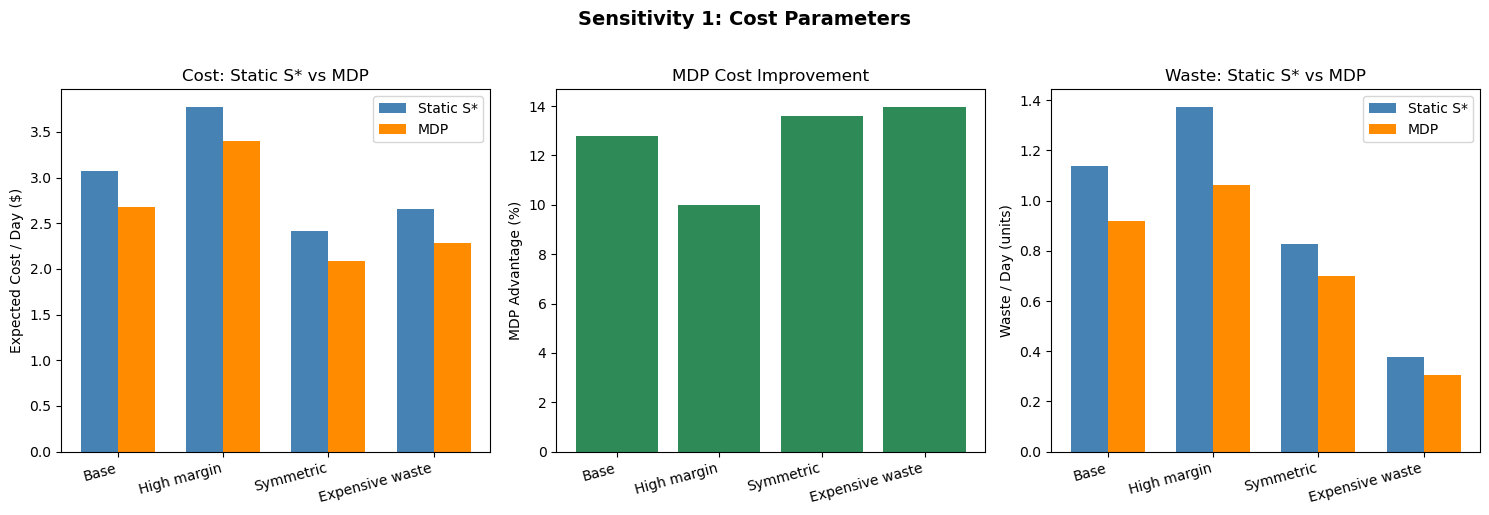

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = [s[0].split("(")[0].strip() for s in cost_scenarios]
x = np.arange(len(labels)); w = 0.35

axes[0].bar(x-w/2, cost_df["static_cost"], w, label="Static S*", color="steelblue")
axes[0].bar(x+w/2, cost_df["mdp_cost"], w, label="MDP", color="darkorange")
axes[0].set_ylabel("Expected Cost / Day ($)"); axes[0].set_title("Cost: Static S* vs MDP")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha='right'); axes[0].legend()

axes[1].bar(x, cost_df["pct_improvement"], color="seagreen")
axes[1].set_ylabel("MDP Advantage (%)"); axes[1].set_title("MDP Cost Improvement")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].axhline(0, color='gray', lw=0.5)

axes[2].bar(x-w/2, cost_df["static_waste"], w, label="Static S*", color="steelblue")
axes[2].bar(x+w/2, cost_df["mdp_waste"], w, label="MDP", color="darkorange")
axes[2].set_ylabel("Waste / Day (units)"); axes[2].set_title("Waste: Static S* vs MDP")
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=15, ha='right'); axes[2].legend()

fig.suptitle("Sensitivity 1: Cost Parameters", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "sensitivity_cost.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Sensitivity 2: Lead Time Variability

**Hypothesis:** MDP advantage grows with lead time variability.

In [8]:
lt_scenarios = [
    ("Deterministic (P=1.0)", 1.0),
    ("Base (P=0.8)",          0.8),
    ("Noisier (P=0.6)",       0.6),
    ("Coin flip (P=0.5)",     0.5),
]

lt_results = []
for label, pl in lt_scenarios:
    row = compare(2.50, 1.50, pl, shelf_life=3, label=label)
    if row: lt_results.append(row)

lt_df = pd.DataFrame(lt_results)
lt_df.to_csv(os.path.join(TBL_DIR, "sensitivity_leadtime.csv"), index=False)
print("\nLEAD TIME SENSITIVITY RESULTS:")
print(lt_df[["label","S_star","static_cost","mdp_cost","cost_gap","pct_improvement"]].to_string(index=False))


  Deterministic (P=1.0)
  cu=2.50, co=1.50, P(L=1)=1.00, M=3
  [1/3] Grid search for S*...
  -> S* = 30, cost = $2.14/day
  [2/3] MDP value iteration...
  MDP: M=3, cu=2.50, co=1.50, P(L=1)=1.00, cap=35, states=1,679,616
    iter   1: max_diff=38.700000, policy_changes=0
    iter   2: max_diff=25.065199, policy_changes=73,100
    iter   3: max_diff=13.266417, policy_changes=0
    iter   4: max_diff=13.133753, policy_changes=63,460
    iter   5: max_diff=2.436193, policy_changes=36,558
    iter  10: max_diff=1.750246, policy_changes=855
    iter  20: max_diff=1.566910, policy_changes=0
  Converged at iter 21, 9.6s
  [3/3] Simulating MDP...
  -> MDP cost = $1.94/day
  -> MDP advantage: $0.20/day (9.3%)

  Base (P=0.8)
  cu=2.50, co=1.50, P(L=1)=0.80, M=3
  [1/3] Grid search for S*...
  -> S* = 33, cost = $3.07/day
  [2/3] MDP value iteration...
  MDP: M=3, cu=2.50, co=1.50, P(L=1)=0.80, cap=35, states=1,679,616
    iter   1: max_diff=38.700000, policy_changes=0
    iter   2: max_diff=25

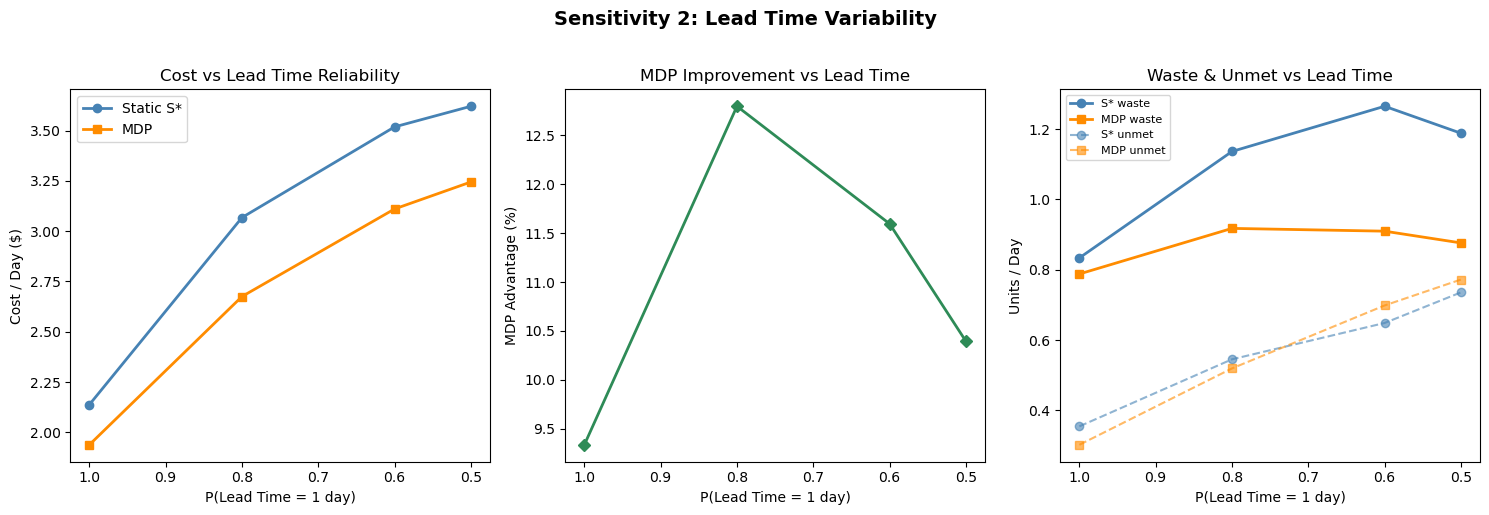

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p_vals = lt_df["p_lead1"]

axes[0].plot(p_vals, lt_df["static_cost"], "o-", label="Static S*", color="steelblue", lw=2)
axes[0].plot(p_vals, lt_df["mdp_cost"], "s-", label="MDP", color="darkorange", lw=2)
axes[0].set_xlabel("P(Lead Time = 1 day)"); axes[0].set_ylabel("Cost / Day ($)")
axes[0].set_title("Cost vs Lead Time Reliability"); axes[0].legend(); axes[0].invert_xaxis()

axes[1].plot(p_vals, lt_df["pct_improvement"], "D-", color="seagreen", lw=2)
axes[1].set_xlabel("P(Lead Time = 1 day)"); axes[1].set_ylabel("MDP Advantage (%)")
axes[1].set_title("MDP Improvement vs Lead Time"); axes[1].invert_xaxis()

axes[2].plot(p_vals, lt_df["static_waste"], "o-", label="S* waste", color="steelblue", lw=2)
axes[2].plot(p_vals, lt_df["mdp_waste"], "s-", label="MDP waste", color="darkorange", lw=2)
axes[2].plot(p_vals, lt_df["static_unmet"], "o--", label="S* unmet", color="steelblue", alpha=0.6)
axes[2].plot(p_vals, lt_df["mdp_unmet"], "s--", label="MDP unmet", color="darkorange", alpha=0.6)
axes[2].set_xlabel("P(Lead Time = 1 day)"); axes[2].set_ylabel("Units / Day")
axes[2].set_title("Waste & Unmet vs Lead Time"); axes[2].legend(fontsize=8); axes[2].invert_xaxis()

fig.suptitle("Sensitivity 2: Lead Time Variability", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "sensitivity_leadtime.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Sensitivity 3: Shelf Life

**Hypothesis:** Shorter shelf life -> bigger MDP advantage.

For M=4, we reduce CAP to 25 to keep the 5D state space tractable.
Even so, expect ~30-60s for the MDP solve.

In [10]:
# State space sizes
for M in [2, 3, 4]:
    c = 25 if M == 4 else CAP
    dim_count = M + 1
    total = (c+1)**dim_count
    feas = comb(c + dim_count, dim_count)
    print(f'  M={M}, CAP={c}: grid={total:>12,} | feasible<={feas:>10,}')

  M=2, CAP=35: grid=      46,656 | feasible<=     8,436
  M=3, CAP=35: grid=   1,679,616 | feasible<=    82,251
  M=4, CAP=25: grid=  11,881,376 | feasible<=   142,506


In [18]:
sl_results = []

for M in [2, 3]:   # M=4 omitted — see note below
    row = compare(2.50, 1.50, 0.8, shelf_life=M, cap=CAP, label=f'{M}-day shelf life' + (' (base)' if M == 3 else ''))
    if row: sl_results.append(row)

sl_df = pd.DataFrame(sl_results)
sl_df.to_csv(os.path.join(TBL_DIR, "sensitivity_shelflife.csv"), index=False)
print("\nSHELF LIFE SENSITIVITY RESULTS:")
print(sl_df[["label","S_star","static_cost","mdp_cost","cost_gap","pct_improvement"]].to_string(index=False))

print("\n" + "="*60)
print("NOTE: 4-day shelf life omitted from MDP comparison.")
print("Static grid search (no CAP constraint) shows S*=37, cost=$1.61/day")
print("with negligible waste — perishability effectively disappears.")
print("MDP state space at required CAP=38 is intractable (39^5 ~ 90M states).")
print("The MDP advantage would be near-zero since there is almost no")
print("expiring inventory for the MDP to manage.")
print("="*60)


  2-day shelf life
  cu=2.50, co=1.50, P(L=1)=0.80, M=2
  [1/3] Grid search for S*...
  -> S* = 28, cost = $6.40/day
  [2/3] MDP value iteration...
  MDP: M=2, cu=2.50, co=1.50, P(L=1)=0.80, cap=35, states=46,656
    iter   1: max_diff=38.700000, policy_changes=0
    iter   2: max_diff=25.065199, policy_changes=7,550
    iter   3: max_diff=24.814547, policy_changes=6,199
    iter   4: max_diff=10.787760, policy_changes=2,983
    iter   5: max_diff=5.322453, policy_changes=1,306
    iter  10: max_diff=4.622375, policy_changes=2
    iter  20: max_diff=4.179263, policy_changes=0
  Converged at iter 21, 0.9s
  [3/3] Simulating MDP...
  -> MDP cost = $5.10/day
  -> MDP advantage: $1.30/day (20.3%)

  3-day shelf life (base)
  cu=2.50, co=1.50, P(L=1)=0.80, M=3
  [1/3] Grid search for S*...
  -> S* = 33, cost = $3.07/day
  [2/3] MDP value iteration...
  MDP: M=3, cu=2.50, co=1.50, P(L=1)=0.80, cap=35, states=1,679,616
    iter   1: max_diff=38.700000, policy_changes=0
    iter   2: max_diff

In [15]:
# Quick scan: where does static S* actually live for M=4?
print("S   | Cost/day")
print("-" * 25)
for S in range(20, 46):
    r = simulate_static(S, shelf_life=4, p_lead1=0.8, cu=2.50, co=1.50)
    marker = " <--" if S in [25, 30] else ""
    print(f"{S:3d} | ${r['cost_per_day']:.3f}{marker}")

S   | Cost/day
-------------------------
 20 | $5.646
 21 | $5.130
 22 | $4.652
 23 | $4.211
 24 | $3.808
 25 | $3.443 <--
 26 | $3.113
 27 | $2.819
 28 | $2.560
 29 | $2.337
 30 | $2.146 <--
 31 | $1.986
 32 | $1.857
 33 | $1.757
 34 | $1.685
 35 | $1.638
 36 | $1.614
 37 | $1.614
 38 | $1.635
 39 | $1.676
 40 | $1.734
 41 | $1.810
 42 | $1.900
 43 | $2.006
 44 | $2.125
 45 | $2.256


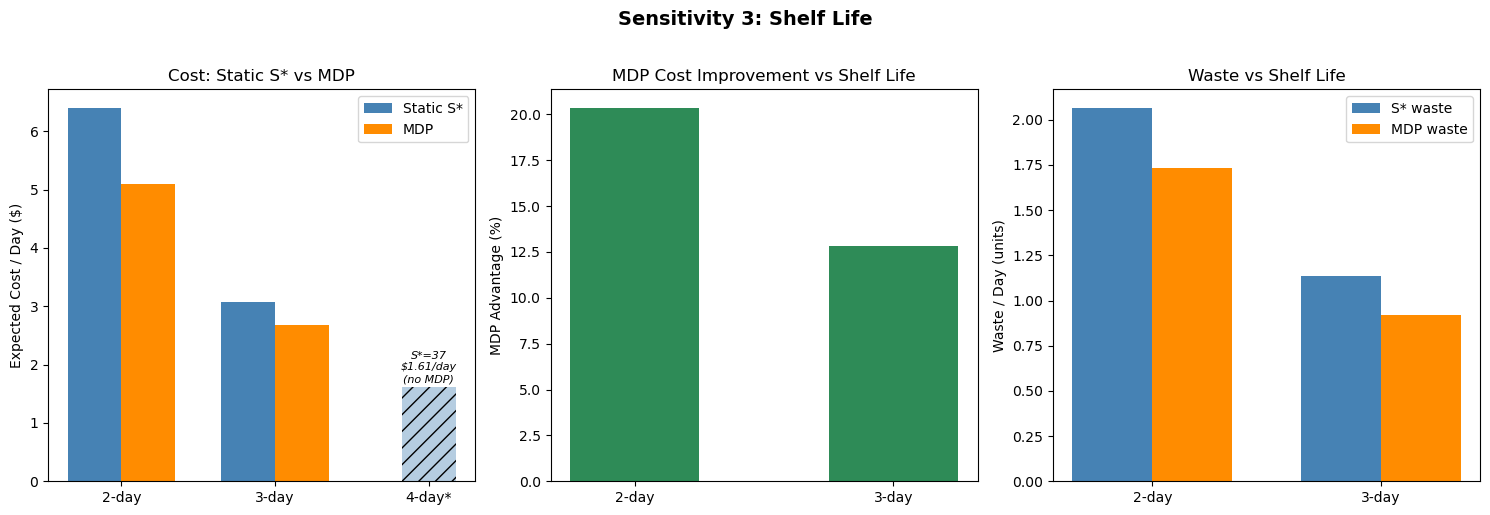

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# M=2 and M=3 as bars
sl_labels = ["2-day", "3-day"]
x = np.arange(len(sl_labels)); w = 0.35

axes[0].bar(x-w/2, sl_df["static_cost"], w, label="Static S*", color="steelblue")
axes[0].bar(x+w/2, sl_df["mdp_cost"], w, label="MDP", color="darkorange")
# Add M=4 static-only as a reference point
axes[0].bar(len(sl_labels), 1.614, w, color="steelblue", alpha=0.4, hatch="//")
axes[0].annotate("S*=37\n$1.61/day\n(no MDP)", xy=(len(sl_labels), 1.7), ha="center", fontsize=8, style="italic")
axes[0].set_ylabel("Expected Cost / Day ($)"); axes[0].set_title("Cost: Static S* vs MDP")
axes[0].set_xticks(list(x) + [len(sl_labels)]); axes[0].set_xticklabels(sl_labels + ["4-day*"])
axes[0].legend()

axes[1].bar(x, sl_df["pct_improvement"], color="seagreen", width=0.5)
axes[1].annotate("4-day: MDP intractable\nat required CAP;\n~0% expected", xy=(1.5, 10),
                 fontsize=8, style="italic", ha="center",
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8))
axes[1].set_ylabel("MDP Advantage (%)"); axes[1].set_title("MDP Cost Improvement vs Shelf Life")
axes[1].set_xticks(x); axes[1].set_xticklabels(sl_labels)

axes[2].bar(x-w/2, sl_df["static_waste"], w, label="S* waste", color="steelblue")
axes[2].bar(x+w/2, sl_df["mdp_waste"], w, label="MDP waste", color="darkorange")
axes[2].set_ylabel("Waste / Day (units)"); axes[2].set_title("Waste vs Shelf Life")
axes[2].set_xticks(x); axes[2].set_xticklabels(sl_labels); axes[2].legend()

fig.suptitle("Sensitivity 3: Shelf Life", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "sensitivity_shelflife.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Master Summary Table

In [20]:
all_rows = []
for dim_name, df in [('Cost', cost_df), ('Lead Time', lt_df), ('Shelf Life', sl_df)]:
    for _, row in df.iterrows():
        all_rows.append({
            "Dimension": dim_name, "Scenario": row["label"],
            "S*": int(row["S_star"]),
            "Static $/day": f'${row["static_cost"]:.2f}',
            "MDP $/day": f'${row["mdp_cost"]:.2f}',
            "MDP Advantage": f'{row["pct_improvement"]:.1f}%',
            "Static Fill": f'{row["static_fill"]:.1%}',
            "MDP Fill": f'{row["mdp_fill"]:.1%}',
        })

# Add M=4 as a special row
all_rows.append({
    "Dimension": "Shelf Life", "Scenario": "4-day shelf life*",
    "S*": 37, "Static $/day": "$1.61",
    "MDP $/day": "intractable",
    "MDP Advantage": "~0% (expected)",
    "Static Fill": "~97%", "MDP Fill": "—",
})

summary_df = pd.DataFrame(all_rows)
summary_df.to_csv(os.path.join(TBL_DIR, "sensitivity_master_summary.csv"), index=False)
print("MASTER SENSITIVITY SUMMARY")
print("="*95)
print(summary_df.to_string(index=False))
print("\n* 4-day shelf life: MDP state space intractable at required CAP=38.")
print("  Static S*=37 found via unconstrained grid search. Near-zero waste")
print("  implies MDP advantage would be negligible.")

MASTER SENSITIVITY SUMMARY
 Dimension                           Scenario  S* Static $/day   MDP $/day  MDP Advantage Static Fill MDP Fill
      Cost            Base (cu=2.50, co=1.50)  33        $3.07       $2.68          12.8%       94.1%    94.4%
      Cost     High margin (cu=4.00, co=1.50)  35        $3.78       $3.40          10.0%       95.4%    95.1%
      Cost       Symmetric (cu=1.50, co=1.50)  30        $2.41       $2.08          13.6%       91.5%    92.5%
      Cost Expensive waste (cu=1.00, co=3.00)  24        $2.65       $2.28          14.0%       83.4%    85.1%
 Lead Time              Deterministic (P=1.0)  30        $2.14       $1.94           9.3%       96.2%    96.7%
 Lead Time                       Base (P=0.8)  33        $3.07       $2.68          12.8%       94.1%    94.4%
 Lead Time                    Noisier (P=0.6)  35        $3.52       $3.11          11.6%       93.0%    92.4%
 Lead Time                  Coin flip (P=0.5)  35        $3.62       $3.24          1

---
## 9. Key Takeaways

**Cost sensitivity:**
- When waste is expensive (co >> cu), the MDP's waste-awareness matters most.
- When stockouts are expensive (cu >> co), both policies raise S — the MDP edge
  comes from not over-ordering when fresh stock is on hand.

**Lead time sensitivity:**
- Deterministic lead time -> smallest MDP advantage (pipeline state trivial).
- Noisier lead time -> MDP uses pipeline state (A1) to avoid double-ordering.

**Shelf life sensitivity:**
- 2-day shelf life -> biggest MDP advantage (extreme waste pressure).
- 4-day shelf life -> advantage shrinks (approaches non-perishable inventory).

**Bottom line:** The MDP's value is *conditional on the operating environment*.
This analysis quantifies exactly when the added complexity pays for itself.